# Link Prediction on an OWL Knowledge Graph with PyKEEN

This notebook implements an **end-to-end link prediction pipeline** for a knowledge graph stored as an **OWL/RDF file**.

It is designed for datasets like your **Hybrid Intelligence knowledge graph** and follows the same logic as the tutorial:
1. parse the OWL graph
2. extract usable factual triples
3. split into train/test
4. train a KG embedding model (**ComplEx** by default)
5. evaluate with ranking metrics
6. generate candidate missing links

## What this notebook assumes
- Your graph is stored in an `.owl`, `.ttl`, `.rdf`, or `.xml` file
- You want to perform **link prediction**
- You are happy to start with **ComplEx**, which is a good default model for multi-relational KGs

## Important note
OWL files often contain many **schema/axiom triples** (`owl:Class`, `rdfs:subClassOf`, restrictions, blank nodes, etc.).
Those are usually **not ideal** for embedding-based link prediction.

So this notebook creates a **filtered factual graph** for machine learning by default:
- removes most OWL/RDFS schema triples
- removes blank nodes
- removes literals as objects
- keeps meaningful entity-to-entity relations
- optionally keeps `rdf:type` when the type is a domain class (not an OWL built-in class)

You can adjust the filters later if needed.

In [2]:
# If needed, uncomment this cell and run once
!pip install rdflib pykeen pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from pathlib import Path
import os
import re
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdflib import Graph, URIRef, BNode, Literal, Namespace
from rdflib.namespace import RDF, RDFS, OWL, XSD

from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen import predict

/Users/ameetran/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Edit the file path below so it points to your OWL file.

You can also configure:
- whether to keep `rdf:type`
- how many training epochs to use
- how many top predictions to inspect

In [63]:
# USER CONFIGURATION


OWL_PATH = "hi_ontology_linked.owl"  
OUTPUT_DIR = Path("pykeen_hi_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Triple filtering options
KEEP_RDF_TYPE = True          # often useful when type assertions connect instances to domain classes
DROP_LITERALS = True          
DROP_BLANK_NODES = True       
ONLY_DOMAIN_RELATIONS = False # 

DOMAIN_NAMESPACE_PREFIXES = [
    "http://www.semanticweb.org/vbr240/ontologies/2022/4/untitled-ontology-51/",
    "http://dbpedia.org/resource/",
    "https://www.wikidata.org/entity/",
    "https://en.wikipedia.org/wiki/",
]

# Training settings
TRAIN_RATIO = 0.9
RANDOM_STATE = 432
MODEL_NAME = "ComplEx"
NUM_EPOCHS = 150
EMBEDDING_DIM = 150
LEARNING_RATE = 1e-3

# Prediction settings
TOP_K = 10

## 2. Helper functions

In [64]:
SCHEMA_NAMESPACES = [
    str(RDF),
    str(RDFS),
    str(OWL),
    str(XSD),
]

SCHEMA_TYPE_OBJECTS = {
    OWL.Class,
    OWL.ObjectProperty,
    OWL.DatatypeProperty,
    OWL.AnnotationProperty,
    OWL.Restriction,
    OWL.Ontology,
    OWL.NamedIndividual,
    RDFS.Class,
    RDF.Property,
}

SCHEMA_PREDICATES_TO_DROP = {
    RDFS.subClassOf,
    RDFS.subPropertyOf,
    RDFS.domain,
    RDFS.range,
    RDFS.label,
    RDFS.comment,
    OWL.equivalentClass,
    OWL.equivalentProperty,
    OWL.disjointWith,
    OWL.inverseOf,
    OWL.sameAs,
    OWL.differentFrom,
    OWL.imports,
    OWL.versionInfo,
    OWL.onProperty,
    OWL.someValuesFrom,
    OWL.allValuesFrom,
    OWL.hasValue,
    OWL.unionOf,
    OWL.intersectionOf,
    OWL.complementOf,
    OWL.oneOf,
    OWL.minCardinality,
    OWL.maxCardinality,
    OWL.cardinality,
    OWL.minQualifiedCardinality,
    OWL.maxQualifiedCardinality,
    OWL.qualifiedCardinality,
}

def short_name(term):
    if isinstance(term, Literal):
        return str(term)
    text = str(term)
    if "#" in text:
        return text.rsplit("#", 1)[-1]
    return text.rstrip("/").rsplit("/", 1)[-1]

def is_schema_namespace(uri):
    uri = str(uri)
    return any(uri.startswith(ns) for ns in SCHEMA_NAMESPACES)

def is_domain_predicate(predicate):
    if not DOMAIN_NAMESPACE_PREFIXES:
        return True
    return any(str(predicate).startswith(ns) for ns in DOMAIN_NAMESPACE_PREFIXES)

def is_clean_entity(node):
    return isinstance(node, URIRef)

def triple_to_strings(s, p, o):
    return str(s), str(p), str(o)

## 3. Load the OWL graph

In [65]:
graph = Graph()
graph.parse(OWL_PATH)

print(f"Loaded RDF graph from: {OWL_PATH}")
print(f"Total raw triples in RDF graph: {len(graph):,}")

Loaded RDF graph from: hi_ontology_linked.owl
Total raw triples in RDF graph: 1,142


## 4. Inspect namespaces
This helps  identify domain namespace(s).  


In [66]:
namespaces = list(graph.namespaces())
pd.DataFrame(namespaces, columns=["prefix", "namespace"]).head(30)

,prefix,namespace
0,brick,https://brickschema.org/schema/Brick#
1,csvw,http://www.w3.org/ns/csvw#
2,dc,http://purl.org/dc/elements/1.1/
3,dcat,http://www.w3.org/ns/dcat#
4,dcmitype,http://purl.org/dc/dcmitype/
5,dcterms,http://purl.org/dc/terms/
6,dcam,http://purl.org/dc/dcam/
7,doap,http://usefulinc.com/ns/doap#
8,foaf,http://xmlns.com/foaf/0.1/
9,geo,http://www.opengis.net/ont/geosparql#


## 5. Build a filtered factual triple set for PyKEEN

Why filtering matters:
- OWL files contain many logical axioms that are useful for reasoning, but not ideal for embedding models
- link prediction works better on a graph of **meaningful factual relations**
- for a first experiment, entity-to-entity triples are the safest option

This cell creates a dataframe with three columns:
- `head`
- `relation`
- `tail`

In [67]:
filtered_triples = []
drop_reasons = Counter()

for s, p, o in graph:
    # blank nodes
    if DROP_BLANK_NODES and (isinstance(s, BNode) or isinstance(o, BNode)):
        drop_reasons["blank_node"] += 1
        continue

    # predicate filtering by namespace
    if ONLY_DOMAIN_RELATIONS and not is_domain_predicate(p):
        drop_reasons["non_domain_predicate"] += 1
        continue

    # remove many schema predicates
    if p in SCHEMA_PREDICATES_TO_DROP:
        drop_reasons["schema_predicate"] += 1
        continue

    # remove literals for first run
    if DROP_LITERALS and isinstance(o, Literal):
        drop_reasons["literal_object"] += 1
        continue

    # require URI entities
    if not is_clean_entity(s):
        drop_reasons["non_uri_subject"] += 1
        continue
    if not isinstance(o, URIRef):
        drop_reasons["non_uri_object"] += 1
        continue

    # special handling for rdf:type
    if p == RDF.type:
        if not KEEP_RDF_TYPE:
            drop_reasons["dropped_rdf_type"] += 1
            continue
        if o in SCHEMA_TYPE_OBJECTS or is_schema_namespace(o):
            drop_reasons["schema_type_object"] += 1
            continue

    filtered_triples.append(triple_to_strings(s, p, o))

triples_df = pd.DataFrame(filtered_triples, columns=["head", "relation", "tail"]).drop_duplicates().reset_index(drop=True)

print(f"Filtered factual triples kept: {len(triples_df):,}")
print(f"Unique entities: {len(set(triples_df['head']).union(set(triples_df['tail']))):,}")
print(f"Unique relations: {triples_df['relation'].nunique():,}")

print("\nDropped triple counts by reason:")
print(pd.Series(drop_reasons).sort_values(ascending=False))

Filtered factual triples kept: 647
Unique entities: 333
Unique relations: 23

Dropped triple counts by reason:
schema_type_object    293
schema_predicate      129
blank_node             73
dtype: int64


In [68]:
triples_df.head(20)

,head,relation,tail
0,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.semanticweb.org/vbr240/ontologies/2...
1,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.semanticweb.org/vbr240/ontologies/2...
2,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...
3,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...
4,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.semanticweb.org/vbr240/ontologies/2...
5,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...
6,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.semanticweb.org/vbr240/ontologies/2...
7,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://www.semanticweb.org/vbr240/ontologies/2...
8,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...
9,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...,http://www.semanticweb.org/vbr240/ontologies/2...


## 6. Optional: make the triples more readable

This table is only for inspection.  
The actual model will still use the full URIs internally.

In [69]:
readable_df = triples_df.copy()
readable_df["head_short"] = readable_df["head"].map(short_name)
readable_df["relation_short"] = readable_df["relation"].map(short_name)
readable_df["tail_short"] = readable_df["tail"].map(short_name)

readable_df[["head_short", "relation_short", "tail_short"]].head(20)

,head_short,relation_short,tail_short
0,EndUserWithLimitedAIExpertise,type,Context
1,ConsequentialistSkew,type,EthicalConsideration
2,legal_ai_1,hasAutonomyLevel,low_auto_case_1
3,BRIDGET_HybridDecisionScenario,hasInteraction,Interaction_Human_BRIDGET
4,warehouse_context_1,type,Context
5,WarehouseAVGscenario,context,TrustCalibration
6,ai_support_role_1,type,AIFinalDecisionMaker
7,doctor_1,type,Human
8,interaction_1,hasCoordinationPattern,seq_coord_1
9,AGV_system,capability,Communication


## 7. Basic graph summary

In [70]:
from urllib.parse import urlparse

def shorten_uri(uri: str) -> str:
    uri = str(uri)
    if "#" in uri:
        return uri.split("#")[-1]
    path = urlparse(uri).path
    if path:
        return path.rstrip("/").split("/")[-1]
    return uri

In [71]:
entity_set = set(triples_df["head"]).union(set(triples_df["tail"]))
relation_counts = triples_df["relation"].value_counts().rename_axis("relation").reset_index(name="count")

rel_counts = triples_df["relation"].value_counts().reset_index()
rel_counts.columns = ["relation", "count"]
rel_counts["relation_short"] = rel_counts["relation"].apply(shorten_uri)

print("Number of factual triples:", len(triples_df))
print("Number of entities:", len(entity_set))
print("Number of relations:", triples_df["relation"].nunique())

rel_counts

Number of factual triples: 647
Number of entities: 333
Number of relations: 23


,relation,count,relation_short
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,221,type
1,http://www.w3.org/2000/01/rdf-schema#seeAlso,101,seeAlso
2,http://www.semanticweb.org/vbr240/ontologies/2...,38,inScenario
3,http://www.semanticweb.org/vbr240/ontologies/2...,38,interactingAgent
4,http://www.semanticweb.org/vbr240/ontologies/2...,38,capability
5,http://www.semanticweb.org/vbr240/ontologies/2...,30,context
6,http://www.semanticweb.org/vbr240/ontologies/2...,28,hasEthicalConsideration
7,http://www.semanticweb.org/vbr240/ontologies/2...,21,processingTask
8,http://www.semanticweb.org/vbr240/ontologies/2...,16,hasInteraction
9,http://www.semanticweb.org/vbr240/ontologies/2...,15,endgoal


<Figure size 1000x500 with 0 Axes>

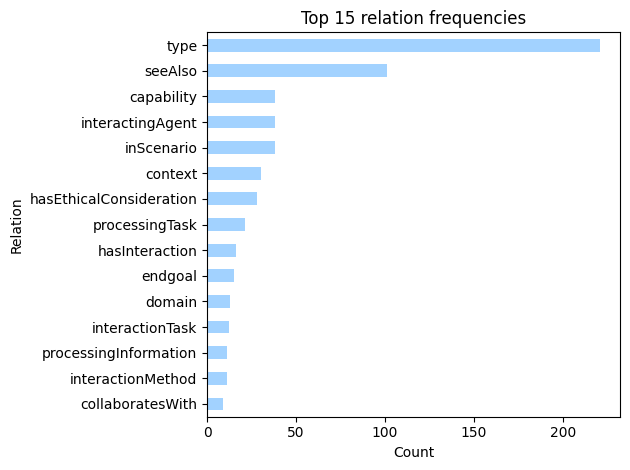

In [72]:
plt.figure(figsize=(10, 5))
rel_counts.head(15).sort_values("count").plot(
    kind="barh", x="relation_short", y="count", legend=False, color="#A2D2FF"
)
plt.xlabel("Count")
plt.ylabel("Relation")
plt.title("Top 15 relation frequencies")
plt.tight_layout()
plt.show()

## 8. Save the filtered triples

PyKEEN expects a file with three columns and **no header** by default.
We will save a TSV file for reproducibility.

In [73]:
triples_path = OUTPUT_DIR / "filtered_triples.tsv"
triples_df.to_csv(triples_path, sep="\t", header=False, index=False)

print(f"Saved PyKEEN triples to: {triples_path.resolve()}")

Saved PyKEEN triples to: /Users/ameetran/Ontology/pykeen_hi_outputs/filtered_triples.tsv


## 9. Create a PyKEEN `TriplesFactory`

In [74]:
tf = TriplesFactory.from_path(str(triples_path))

print(tf)
print("Number of entities in factory:", tf.num_entities)
print("Number of relations in factory:", tf.num_relations)
print("Number of triples in factory:", tf.num_triples)

TriplesFactory(num_entities=333, num_relations=23, create_inverse_triples=False, num_triples=647, path="/Users/ameetran/Ontology/pykeen_hi_outputs/filtered_triples.tsv")
Number of entities in factory: 333
Number of relations in factory: 23
Number of triples in factory: 647


## 10. Split into train and test

In [75]:
train_tf, test_tf = tf.split([TRAIN_RATIO, 1 - TRAIN_RATIO], random_state=RANDOM_STATE)

print("Training triples:", train_tf.num_triples)
print("Testing triples:", test_tf.num_triples)

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [277, 65]


Training triples: 582
Testing triples: 65


## 11. Train the link prediction model

This follows the tutorial structure closely, using **ComplEx** as a default.

In [76]:
result = pipeline(
    model=MODEL_NAME,
    training=train_tf,
    testing=test_tf,
    training_kwargs={"num_epochs": NUM_EPOCHS},
    dimensions=EMBEDDING_DIM,
    optimizer="adam",
    optimizer_kwargs={"lr": LEARNING_RATE},
    loss="pairwisehinge",
    regularizer="LP",
    regularizer_kwargs={"p": 3, "weight": 1e-5},
    negative_sampler="basic",
    negative_sampler_kwargs={"filtered": True},
    random_seed=RANDOM_STATE,
)

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
Training epochs on cpu: 100%|██████████| 150/150 [00:27<00:00,  5.52epoch/s, loss=1.81, prev_loss=2.21]
Evaluating on cpu:   0%|          | 0.00/65.0 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 65.0/65.0 [00:00<00:00, 920triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 0.08s seconds


## 12. Evaluation metrics
Common ranking metrics:
- **MRR**: Mean Reciprocal Rank. Higher is better.
- **Hits@10**: proportion of cases where the true answer appears in the top 10 predictions.

In [77]:
mrr = result.get_metric("mrr")
hits10 = result.get_metric("hits_at_10")
hits1 = result.get_metric("hits_at_1")
hits3 = result.get_metric("hits_at_3")

metrics_df = pd.DataFrame([
    {"metric": "MRR", "value": mrr},
    {"metric": "Hits@1", "value": hits1},
    {"metric": "Hits@3", "value": hits3},
    {"metric": "Hits@10", "value": hits10},
])

metrics_df

,metric,value
0,MRR,0.015686
1,Hits@1,0.000000
2,Hits@3,0.000000
3,Hits@10,0.030769


## 13. Save the trained model and results

In [78]:
result.save_to_directory(OUTPUT_DIR / "trained_model")

metrics_df.to_csv(OUTPUT_DIR / "evaluation_metrics.csv", index=False)

print(f"Saved model/results to: {(OUTPUT_DIR / 'trained_model').resolve()}")

INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=333, num_relations=23, create_inverse_triples=False, num_triples=582, path="/Users/ameetran/Ontology/pykeen_hi_outputs/filtered_triples.tsv") to file:///Users/ameetran/Ontology/pykeen_hi_outputs/trained_model/training_triples
INFO:pykeen.pipeline.api:Saved to directory: /Users/ameetran/Ontology/pykeen_hi_outputs/trained_model


Saved model/results to: /Users/ameetran/Ontology/pykeen_hi_outputs/trained_model


## 14. Predict missing tails for a chosen `(head, relation, ?)` query

Replace the example values below with **URIs that actually exist in your graph**.

A good use case for your HI graph would be something like:
- `(AVG_system, capability, ?)`
- `(scenario_Y, hasGoal, ?)`
- `(agent_Z, hasCapability, ?)`

In [79]:
example_head = triples_df.iloc[4]["head"]
example_relation = triples_df.iloc[4]["relation"]

tail_predictions = predict.predict_target(
    model=result.model,
    head=example_head,
    relation=example_relation,
    triples_factory=tf,
).df

In [80]:
tail_col = "tail_label" if "tail_label" in tail_predictions.columns else "tail_id"

tail_predictions["head_short"] = short_name(example_head)
tail_predictions["relation_short"] = short_name(example_relation)
tail_predictions["tail_short"] = tail_predictions[tail_col].apply(short_name)

tail_predictions[["head_short", "relation_short", "tail_short", "score"]].head(TOP_K)

,head_short,relation_short,tail_short,score
41,warehouse_context_1,type,Labour_economics,85.198120
11,warehouse_context_1,type,Capability,60.348640
139,warehouse_context_1,type,GenerationalLevels,60.038513
3,warehouse_context_1,type,Antibiotic,56.358681
34,warehouse_context_1,type,Information_processing,54.770214
326,warehouse_context_1,type,Explainable_artificial_intelligence,54.743797
127,warehouse_context_1,type,ExplanationType,54.019672
269,warehouse_context_1,type,high_trust_case_1,52.223698
57,warehouse_context_1,type,Risk_management,51.580837
184,warehouse_context_1,type,LearningOrganization,51.550224


## 15. Predict missing heads for a chosen `(?, relation, tail)` query

In [81]:
example_tail = triples_df.iloc[4]["tail"]

head_predictions = predict.predict_target(
    model=result.model,
    relation=example_relation,
    tail=example_tail,
    triples_factory=tf,
).df

head_col = "head_label" if "head_label" in head_predictions.columns else "head_id"

head_predictions["tail_short"] = short_name(example_tail)
head_predictions["relation_short"] = short_name(example_relation)
head_predictions["head_short"] = head_predictions[head_col].apply(short_name)

head_predictions[["head_short", "relation_short", "tail_short", "score"]].head(TOP_K)

,head_short,relation_short,tail_short,score
21,Decision_support_system,type,Context,67.757835
253,ai_support_role_2,type,Context,55.985508
252,ai_support_role_1,type,Context,54.483944
283,interaction_6,type,Context,49.581230
226,SequentialDecisionMaking,type,Context,48.880783
99,CollaborativeDiagnosis,type,Context,46.773857
71,AGV_Processing,type,Context,46.189056
165,HybridHumanAIInteraction,type,Context,45.525974
123,ExpertiseWeightedDecisionMaking,type,Context,43.708260
119,EndUserWithLimitedAIExpertise,type,Context,43.306908
